### Description
Explore Boston buildings data to identify potential attributes that could be 
used to eventually build an ML model or neural network.

Key Factors:
* Environmental
* Social
* Economic

Ethical Concerns: Consider that certain attributes may further socioeconomic
discrimination (redlining, food deserts, etc.).

### Data Source 
https://data.boston.gov/dataset/boston-buildings-inventory

### Label
`use_class`: building use classification

### Relevant Attributes
Note: The following attributes may not necessarily be used, but they were
considered to be relevant to the goals of this project.

Building Attributes: 
* `yr_built`: year built
* `sqft`: square feet
* `existing_ashp`: air-source heat pump installed
* `existing_gshp`: ground-source heat pump installed
* `existing_shw`: solar hot water system installed
* `historic_district`: located in a historic district
* `landmark`: located in a landmark district

Environmental Attributes: 
* `flood`: flood zone
* `stormwater`: stormwater flood zone

Social Attributes: 
* `ct_perc_children_under_5`: % of population under 5 years old
* `ct_perc_over_65`: % of population over 65 years old

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

In [77]:
FILENAME = "data/boston_buildings.csv"
LABEL = "use_class"
BOOLS = ["historic_district", "landmark", "flood", "stormwater"]
QUANT = ["yr_built", "sqft", "ct_perc_children_under_5", "ct_perc_over_65"]
ALL = [LABEL, *BOOLS, *QUANT]

`existing_ashp`, `existing_gshp`, and `existing_shw` data was too sparse to
be usable attributes.

In [78]:
df = pd.read_csv(FILENAME)
df = df[ALL].dropna()
df

/var/folders/k8/3s73cc5x32b13wxlg0_xqlk80000gn/T/ipykernel_59806/2056761157.py:1: DtypeWarning: Columns (1,40,44,47,51,53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILENAME)


,use_class,historic_district,landmark,flood,stormwater,yr_built,sqft,ct_perc_children_under_5,ct_perc_over_65
1,Residential,f,f,f,f,1940.0,1326.0,20.926988,9.145869
2,Residential,f,f,t,t,1875.0,1344.0,21.730217,16.892169
31,Residential,f,f,f,f,1865.0,1590.0,10.218978,13.029197
38,Commercial,f,f,f,f,1940.0,5332.0,30.579216,7.580920
112,Residential,f,t,f,f,2000.0,232116.0,7.878685,13.758048
...,...,...,...,...,...,...,...,...,...
98924,Residential,f,f,f,f,2007.0,1863.0,23.207269,11.738703
98925,Residential,f,f,f,f,2000.0,3140.0,10.828648,14.910780
98926,Residential,f,f,f,f,2005.0,2611.0,19.217745,17.660007
98927,Residential,f,f,f,f,2013.0,2129.0,10.218978,13.029197


In [79]:
df[BOOLS] = df[BOOLS].replace({"f": 0, "t": 1})
df[BOOLS]

/var/folders/k8/3s73cc5x32b13wxlg0_xqlk80000gn/T/ipykernel_59806/948076763.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[BOOLS] = df[BOOLS].replace({"f": 0, "t": 1})


,historic_district,landmark,flood,stormwater
1,0,0,0,0
2,0,0,1,1
31,0,0,0,0
38,0,0,0,0
112,0,1,0,0
...,...,...,...,...
98924,0,0,0,0
98925,0,0,0,0
98926,0,0,0,0
98927,0,0,0,0


In [80]:
df

,use_class,historic_district,landmark,flood,stormwater,yr_built,sqft,ct_perc_children_under_5,ct_perc_over_65
1,Residential,0,0,0,0,1940.0,1326.0,20.926988,9.145869
2,Residential,0,0,1,1,1875.0,1344.0,21.730217,16.892169
31,Residential,0,0,0,0,1865.0,1590.0,10.218978,13.029197
38,Commercial,0,0,0,0,1940.0,5332.0,30.579216,7.580920
112,Residential,0,1,0,0,2000.0,232116.0,7.878685,13.758048
...,...,...,...,...,...,...,...,...,...
98924,Residential,0,0,0,0,2007.0,1863.0,23.207269,11.738703
98925,Residential,0,0,0,0,2000.0,3140.0,10.828648,14.910780
98926,Residential,0,0,0,0,2005.0,2611.0,19.217745,17.660007
98927,Residential,0,0,0,0,2013.0,2129.0,10.218978,13.029197


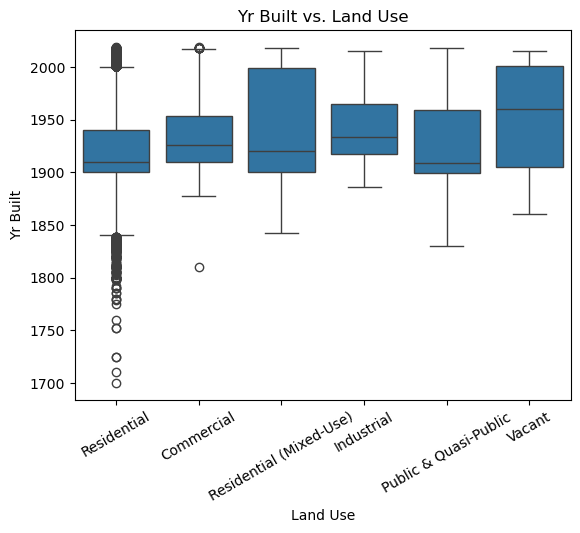

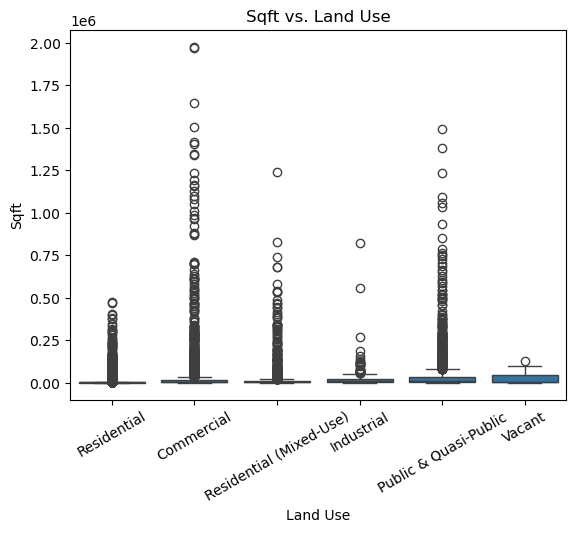

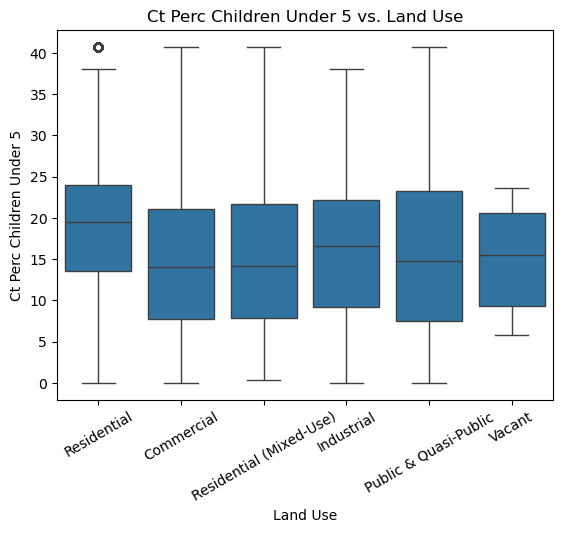

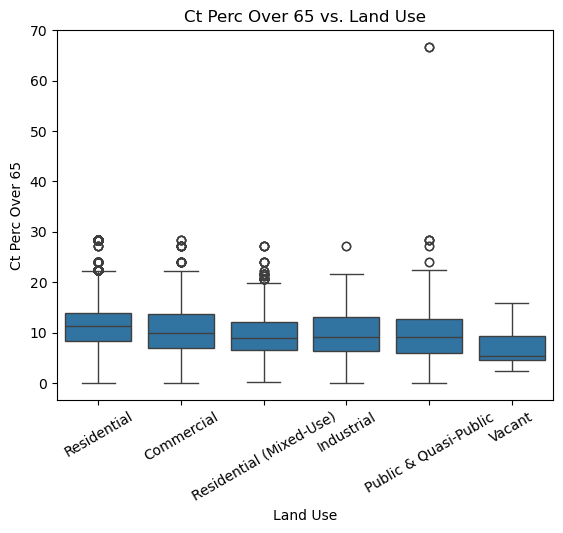

In [81]:
# graph quantitative features against the label to investigate relationships
for feature in QUANT:
    sns.boxplot(data=df, x=LABEL, y=feature)
    feature = feature.replace("_", " ").title()
    plt.title(f"{feature} vs. Land Use")
    plt.xlabel("Land Use")
    plt.ylabel(f"{feature}")
    plt.xticks(rotation=30)
    plt.show()

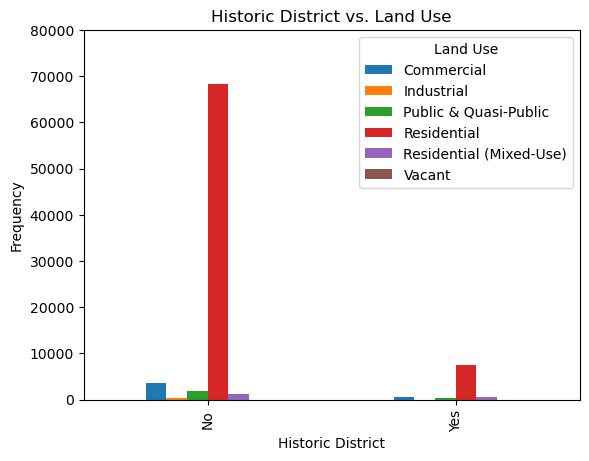

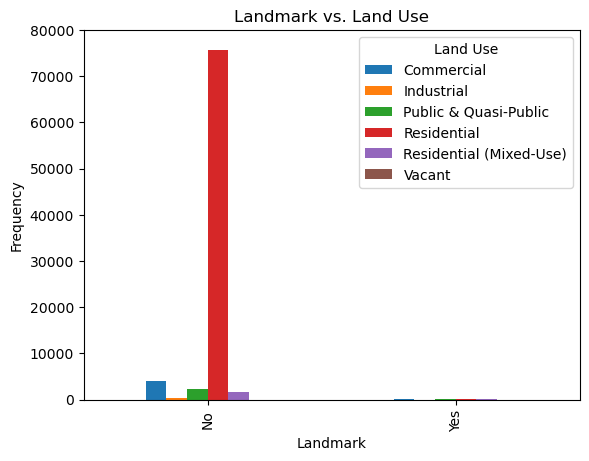

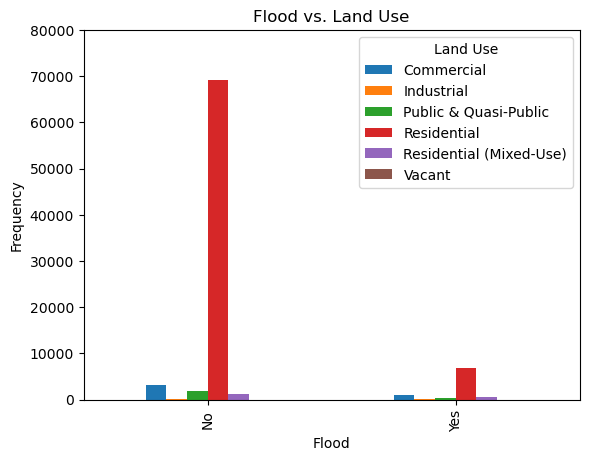

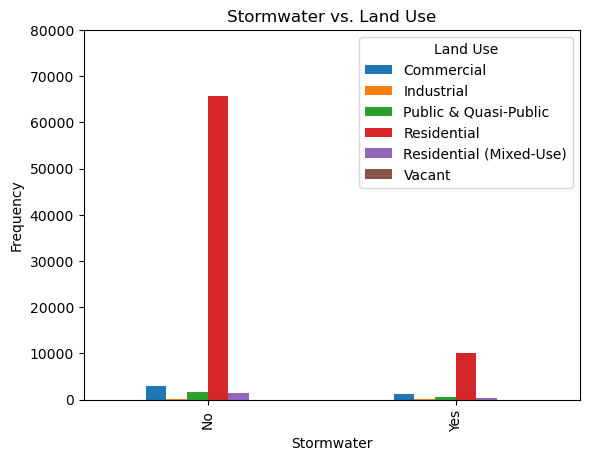

In [82]:
# graph categorical features against the label to investigate relationships
for feature in BOOLS:
    pd.crosstab(df[feature], df[LABEL]).plot(kind="bar")
    feature = feature.replace("_", " ").title()
    plt.title(f"{feature} vs. Land Use")
    plt.legend(title="Land Use")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.xticks([0, 1], ["No", "Yes"])
    plt.ylim(0, 80000)
    plt.show()

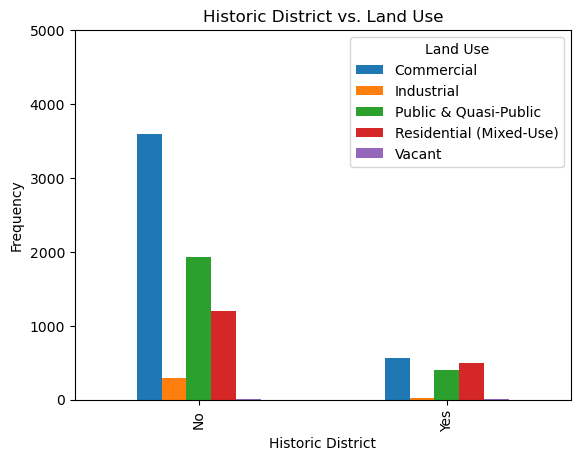

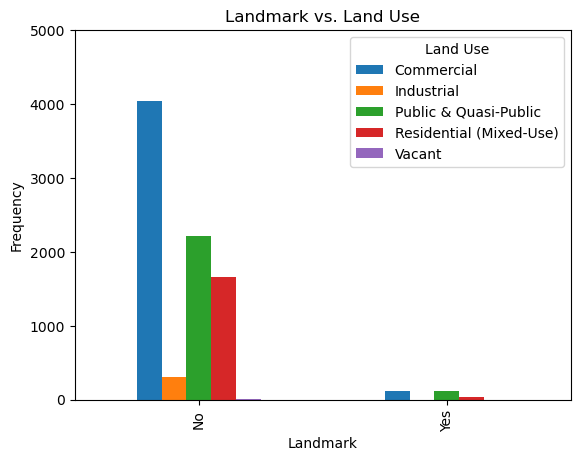

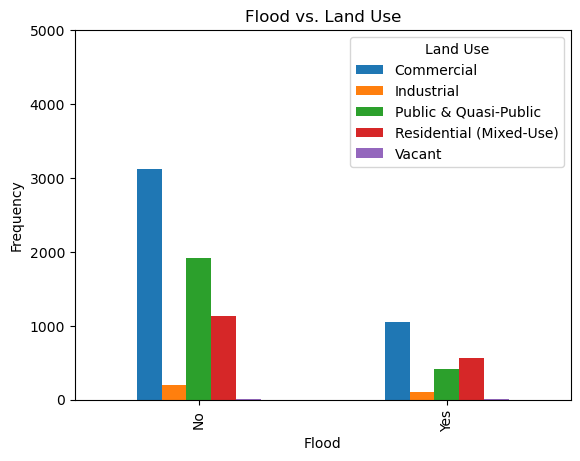

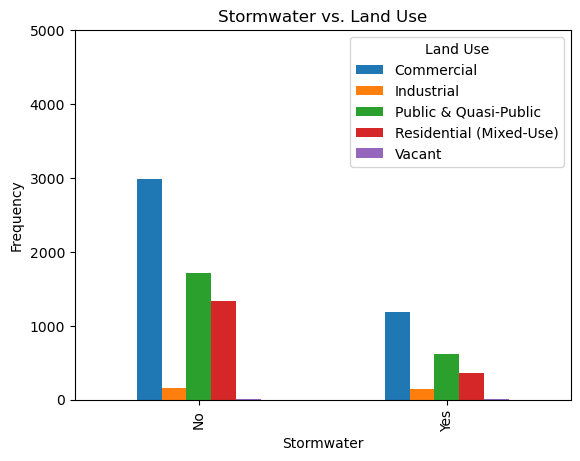

In [83]:
# exclude residential land use to get a better understanding of other land uses
# i like hot men
# hehehehahahhahahaha

EXCLUDE = "Residential"

for feature in BOOLS:
    pd.crosstab(df[feature], df[df[LABEL] != EXCLUDE][LABEL]).plot(kind="bar")
    feature = feature.replace("_", " ").title()
    plt.title(f"{feature} vs. Land Use")
    plt.legend(title="Land Use")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.xticks([0, 1], ["No", "Yes"])
    plt.ylim(0, 5000)
    plt.show()